<a href="https://colab.research.google.com/github/CharlesKwak/environment-shirtdaffodil-production/blob/master/HF_SAM_Blur_Faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Open Vacabulary Object Detection
#### SAM : 얼굴 가리기

#### 모델 Card : https://huggingface.co/google/owlvit-base-patch32


#### Simple Open-Vocabulary Object Detection with Vision Transformers ( https://arxiv.org/abs/2205.06230 )

In [ ]:
!pip install transformers

#### Helper 함수

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from skimage import measure
import random
from PIL import Image
import json


def preprocess_outputs(output):
    input_scores = [x["score"] for x in output]
    input_labels = [x["label"] for x in output]
    input_boxes = []
    for i in range(len(output)):
        input_boxes.append([*output[i]["box"].values()])
    input_boxes = [input_boxes]
    return input_scores, input_labels, input_boxes


def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(
        plt.Rectangle((x0, y0), w, h, edgecolor="green", facecolor=(0, 0, 0, 0), lw=2)
    )


def show_boxes_on_image(raw_image, boxes):
    plt.figure(figsize=(10, 10))
    plt.imshow(raw_image)
    for box in boxes:
        show_box(box, plt.gca())
    plt.axis("on")
    plt.show()


def show_boxes_and_labels_on_image(raw_image, boxes, labels, scores):
    plt.figure(figsize=(10, 10))
    plt.imshow(raw_image)
    for i, box in enumerate(boxes):
        show_box(box, plt.gca())
        plt.text(
            x=box[0],
            y=box[1] - 12,
            s=f"{labels[i]}: {scores[i]:,.4f}",
            c="beige",
            path_effects=[pe.withStroke(linewidth=4, foreground="darkgreen")],
        )
    plt.axis("on")
    plt.show()


def show_masks_on_image(raw_image, masks):
    # Create a mask image (assuming binary mask)
    image_with_mask = raw_image.convert("RGBA")

    for mask in masks:
        mask = mask.cpu().numpy()

        width, height = image_with_mask.size
        mask_array = np.zeros((height, width, 4), dtype=np.uint8)
        color = [random.randint(0, 255), random.randint(0, 255), random.randint(0, 255), 150]

        mask_array[mask, :] = color
        mask_image = Image.fromarray(mask_array)


        # Overlay the mask on the image
        image_with_mask = Image.alpha_composite(
            image_with_mask,
            mask_image)

    # Display the result
    return image_with_mask

def show_multiple_masks_on_image(raw_image, masks, scores):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(np.array(raw_image))
    for idx in range(len(masks[0])):
        mask = masks[0][idx][0].cpu().detach()
        show_mask(mask, ax, random_color=True)
    ax.axis("off")
    plt.show()


def show_binary_mask(masks, scores):
    if len(masks.shape) == 4:
        masks = masks.squeeze()
    if scores.shape[0] == 1:
        scores = scores.squeeze()

    fig, ax = plt.subplots(figsize=(10, 10))
    idx = scores.tolist().index(max(scores))
    mask = masks[idx].cpu().detach()
    ax.imshow(np.array(masks[0, :, :]), cmap="gray")
    score = scores[idx]
    ax.title.set_text(f"Score: {score.item():.3f}")
    ax.axis("off")
    plt.show()


def make_sam_mask(boolean_mask):
    contours = measure.find_contours(boolean_mask, 0.5)
    mask_points = []
    for contour in contours:
        contour = np.flip(contour, axis=1)
        segmentation = contour.ravel().tolist()
        mask_points.append(segmentation)
    return mask_points


def make_coco_boxes(detections_boxes):

    """Convert torch tensor Pascal VOC bboxes to COCO format for Comet annotations"""

    list_boxes = detections_boxes
    coco_boxes = [
        [
            list_boxes[0],
            list_boxes[1],
            (list_boxes[2] - list_boxes[0]),
            (list_boxes[3] - list_boxes[1]),
        ]
    ]
    return coco_boxes


def make_bbox_annots(input_scores, input_labels, input_boxes, image_metadata):

    if len(input_boxes[0]) == 0:
        return None

    annotations = [
        {
            "name": "bbox annots",
            "data": [],
            "metadata": image_metadata,
        }
    ]

    for i in range(len(input_boxes[0])):
        annotations[0]["data"].append(
            {
                "label": input_labels[i],
                "score": round((input_scores[i] * 100), 2),
                # bboxes in pascal_voc format, return in coco format for Comet annotations
                "boxes": make_coco_boxes(input_boxes[0][i]),
                "points": None,
            }
        )
    annotations = json.loads(json.dumps(annotations))
    return annotations


def make_mask_annots(input_masks,
                     input_labels,
                     image_metadata
                    ):

    if len(input_masks[0]) == 0:
        return None

    annotations = [
        {
            "name": "mask annots",
            "data": [],
            "meta_data": image_metadata,
        }
    ]

    for i in range(len(input_masks)):
        annotations[0]["data"].append(
            {
                "label": input_labels[i],
                "score": 100.00,
                "points": make_sam_mask(input_masks[i]),
            }
        )
    annotations = json.loads(json.dumps(annotations))
    return annotations


#### 테스트용 이미지 download

In [ ]:
# Local Disk에 있는 사진으로 요쳥보내기
#
import urllib.request
import os

# img_file =  'two_persons.jpg'
# img_file = "kittens.jpg"
img_file = "sam_dog.jpg"

# 이미지 다운로드
img_url = "https://github.com/swkang1062/Test/blob/main/" + img_file + "?raw=true"
img_dir = "./"

img_path = os.path.join(img_dir, img_file)
urllib.request.urlretrieve(img_url, img_path)

('./sam_dog.jpg', <http.client.HTTPMessage at 0x7d3784d50910>)

In [ ]:
from PIL import Image
raw_image = Image.open(img_file)
raw_image

In [ ]:
from transformers import pipeline

In [ ]:
# Load the model
detector = pipeline(
    model="google/owlvit-base-patch32",
    task="zero-shot-object-detection"
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/613M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


In [ ]:
# What you want to identify in the image
text_prompt = "dog"
# text_prompt = 'cat'

In [ ]:
output = detector(
    raw_image,
    candidate_labels = [text_prompt]
)

In [ ]:
# Print the output to identify the bounding boxes detected
output

[{'score': 0.1872650533914566,
  'label': 'dog',
  'box': {'xmin': 591, 'ymin': 259, 'xmax': 1517, 'ymax': 1623}},
 {'score': 0.1735612154006958,
  'label': 'dog',
  'box': {'xmin': 1349, 'ymin': 485, 'xmax': 2074, 'ymax': 1623}}]

#### 결과 확인

In [ ]:
input_scores, input_labels, input_boxes = preprocess_outputs(output)

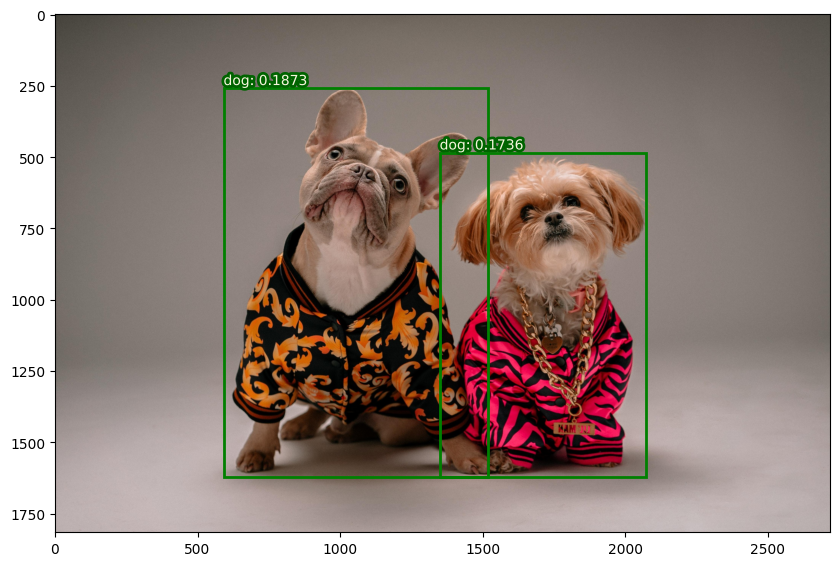

In [ ]:
# Show the image with the bounding boxes
show_boxes_and_labels_on_image(
    raw_image,
    input_boxes[0],
    input_labels,
    input_scores
)

#### SAM 모델

#### 모델 card  : https://huggingface.co/CIDAS/clipseg-rd64-refined


In [ ]:
from PIL import Image
import torch
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
import matplotlib.pyplot as plt

In [ ]:
# 모델과 프로세서 로드 (여기서는 CIDAS/clipseg-rd64-refined 버전 사용)
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.73k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

In [ ]:
import numpy as np

In [ ]:
# Create a list of positive labels of same length as the number of predictions generated above
labels = np.repeat(1, len(output))

In [ ]:
# Print the labels
labels

array([1, 1])

#### 이미지 Editing : 얼굴 가리기

In [ ]:
from PIL import Image

In [ ]:
# Local Disk에 있는 사진으로 요쳥보내기
#
import urllib.request
import os


img_file = "people.jpg"

# 이미지 다운로드
img_url = "https://github.com/swkang1062/Test/blob/main/" + img_file + "?raw=true"
img_dir = "./"

img_path = os.path.join(img_dir, img_file)
urllib.request.urlretrieve(img_url, img_path)

('./people.jpg', <http.client.HTTPMessage at 0x7d36182b47d0>)

In [ ]:
raw_image = Image.open(img_path)
raw_image

In [ ]:
raw_image.size

(9000, 6000)

#### 이미지 Size 변경

In [ ]:
# Calculate width percent to maintain aspect ratio in resize transformation
mywidth = 352
wpercent = mywidth / float(raw_image.size[0])
wpercent

0.03911111111111111

In [ ]:
# Calculate height percent to maintain aspect ratio in resize transformation
# hsize = int( float(raw_image.size[1]) * wpercent )
# hsize

hsize = mywidth

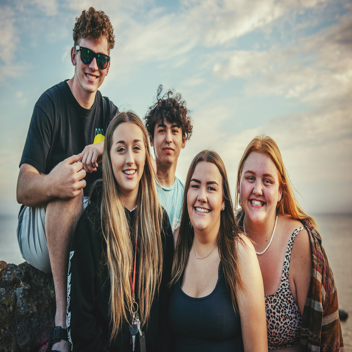

In [ ]:
# Resize the image
resized_image = raw_image.resize([mywidth, hsize])
resized_image

In [ ]:
resized_image.size

(352, 352)

In [ ]:
# Save the resized image
image_path_resized = "people_resized.jpg"
raw_image.save(image_path_resized)

#### 얼굴 탐지

In [ ]:
# 텍스트 프롬프트 입력 (예: 'dog' 혹은 원하는 객체명)
# text_prompt = "dog"
# text_prompt = "human face"
text_prompt = "face"
# text_prompt = "human face with sunglasses"

# text_prompt = "사람 얼굴"

In [ ]:
# 전처리: 텍스트와 이미지를 모델 입력 형식으로 변환
inputs = processor(text=[text_prompt], images=resized_image, return_tensors="pt")

In [ ]:
# 모델 추론: segmentation mask 예측
outputs = model(**inputs)
# print("outputs == ", outputs)

outputs ==  CLIPSegImageSegmentationOutput(loss=None, logits=tensor([[[-9.2439, -9.1616, -9.2457,  ..., -8.6036, -8.5942, -8.6546],
         [-9.1538, -8.8186, -8.9796,  ..., -8.5714, -8.6383, -8.6306],
         [-8.8514, -8.6544, -8.9141,  ..., -8.4224, -8.5585, -8.5866],
         ...,
         [-8.0706, -7.9619, -7.9692,  ..., -6.8465, -7.0590, -7.2026],
         [-8.1580, -8.1156, -8.0988,  ..., -6.9800, -7.2184, -7.3644],
         [-8.3407, -8.3960, -8.2360,  ..., -7.2916, -7.3647, -7.5955]]],
       grad_fn=<SqueezeBackward1>), conditional_embeddings=tensor([[ 3.8734e-01,  2.1786e-01,  3.4569e-01, -2.9015e-01,  8.2088e-02,
          5.9569e-01, -1.3963e-01, -6.8150e-02, -1.3884e-02,  6.2723e-02,
         -1.1142e-02, -2.4175e-01,  4.5316e-01, -2.8437e-01,  2.2591e-01,
          2.5501e-01,  2.1444e-01, -4.2651e-02, -6.7522e-02, -1.1971e-01,
          2.4540e-01,  2.2506e-01, -9.3823e-02, -4.8034e-03,  1.4948e-01,
          2.8337e-01, -2.1070e-01,  2.6169e-01,  1.2651e-02, -2.7930

In [ ]:
print("outputs.logits.sigmoid().shape == ", outputs.logits.sigmoid().shape)

outputs.logits.sigmoid().shape ==  torch.Size([1, 352, 352])


In [ ]:
# logits 값을 sigmoid 처리하여 마스크로 변환
mask = outputs.logits.sigmoid()[0].detach().cpu().numpy()

print("mask == ", mask)

mask ==  [[9.6693933e-05 1.0498424e-04 9.6511729e-05 ... 1.8340994e-04
  1.8513692e-04 1.7428838e-04]
 [1.0580171e-04 1.4792716e-04 1.2594181e-04 ... 1.8941086e-04
  1.7715953e-04 1.7852509e-04]
 [1.4315950e-04 1.7432313e-04 1.3445527e-04 ... 2.1983009e-04
  1.9186293e-04 1.8654743e-04]
 ...
 [3.1248500e-04 3.4836124e-04 3.4583101e-04 ... 1.0620893e-03
  8.5893460e-04 7.4406690e-04]
 [2.8634339e-04 2.9874040e-04 3.0380063e-04 ... 9.2940219e-04
  7.3241891e-04 6.3302193e-04]
 [2.3853806e-04 2.2572024e-04 2.6485958e-04 ... 6.8074896e-04
  6.3278788e-04 5.0247775e-04]]


#### Blur the entire image first

In [ ]:
from PIL.ImageFilter import GaussianBlur

In [ ]:
blurred_img = resized_image.filter(GaussianBlur(radius=5))

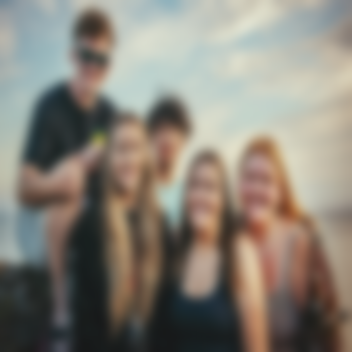

In [ ]:
blurred_img

In [ ]:
# Create an array of zeroes of the same shape as our image mask
basic_mask = np.zeros(mask.shape)

In [ ]:

# Add each output mask to the total_mask
total_mask = np.add(basic_mask,mask) > 0.1

# print("total_mask.shape == ", total_mask.shape)
# three_D_mask = np.expand_dims(total_mask, axis=-1)
# print("three_D_mask.shape == ", three_D_mask.shape)
# resized_mask = np.resize(total_mask, (hsize, mywidth)) > 0.3


print("total_mask.shape == ", total_mask.shape)



total_mask.shape ==  (352, 352)


In [ ]:
# Where there is any value other than zero (where any masks exist), show the blurred image
# Else, show the original (unblurred) image
output = np.where(
    np.expand_dims(total_mask != 0, axis=2),
    blurred_img,
    resized_image
)

print("output.shape == ", output.shape )

output.shape ==  (352, 352, 3)


In [ ]:
import matplotlib.pyplot as plt

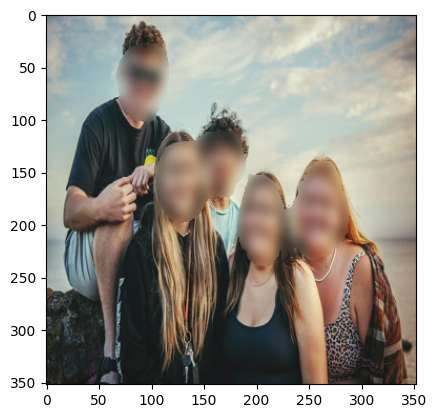

In [ ]:
# Print image with faces blurred
plt.imshow(output)